# Imports

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath("../src"))

from config import CITIES, DAILY_VARIABLES
from features import build_features, get_feature_columns, get_target_columns

# Load raw historical data

In [2]:
raw_dir = Path("../data/raw/historical")

files = sorted(raw_dir.glob("*.parquet"))
if not files:
    raise FileNotFoundError(f"No parquet files found in {raw_dir}")

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print(df.shape)
print(df.head())
print(df.columns.tolist())

(21920, 9)
        time  temperature_2m_max  precipitation_sum  wind_speed_10m_max  \
0 2020-01-01                11.4                0.0                11.4   
1 2020-01-01                11.4                0.0                11.4   
2 2020-01-02                 8.6                0.0                33.0   
3 2020-01-02                 8.6                0.0                33.0   
4 2020-01-03                 7.6                1.7                24.1   

   relative_humidity_2m_mean  cloud_cover_mean  apparent_temperature_max  \
0                         90                30                       8.8   
1                         90                30                       8.8   
2                         88                50                       3.2   
3                         88                50                       3.2   
4                         83                96                       3.3   

   sunshine_duration  city  
0           31885.13  Baku  
1           31885.13  B

# Basic validation

In [3]:
required_cols = [
    "time",
    "city",
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "apparent_temperature_max",
    "sunshine_duration",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Duplicate rows:", df.duplicated().sum())
print("Date range:", df["time"].min(), "→", df["time"].max())
print(df.isna().sum())

Duplicate rows: 10960
Date range: 2020-01-01 00:00:00 → 2025-12-31 00:00:00
time                         0
temperature_2m_max           0
precipitation_sum            0
wind_speed_10m_max           0
relative_humidity_2m_mean    0
cloud_cover_mean             0
apparent_temperature_max     0
sunshine_duration            0
city                         0
dtype: int64


# Feature engineering

In [4]:
df_feat, le = build_features(df)

print(df_feat.shape)
print(df_feat.head())

(21890, 20)
        time  temperature_2m_max  precipitation_sum  wind_speed_10m_max  \
0 2020-01-04                 8.4                0.2                22.7   
1 2020-01-04                 8.4                0.2                22.7   
2 2020-01-05                 7.7                2.6                12.6   
3 2020-01-05                 7.7                2.6                12.6   
4 2020-01-06                 9.8                0.0                 9.5   

   relative_humidity_2m_mean  cloud_cover_mean  apparent_temperature_max  \
0                         83                98                       4.6   
1                         83                98                       4.6   
2                         91               100                       6.4   
3                         91               100                       6.4   
4                         91                65                       7.7   

   sunshine_duration  city  month  day_of_month  temperature_lag_1  \
0         

# Supervised target creation

In [5]:
def make_supervised(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    out = df.copy().sort_values(["city", "time"]).reset_index(drop=True)

    target_cols = get_target_columns()

    for col in target_cols:
        out[f"{col}_target"] = out.groupby("city")[col].shift(-horizon)

    out = out.dropna().reset_index(drop=True)
    return out

# Feature columns

In [7]:
feature_cols = [
    "city_encoded",
    "month",
    "day_of_month",
    "apparent_temperature_max",
    "sunshine_duration",
    "temperature_lag_1",
    "precipitation_lag_1",
    "wind_lag_1",
    "humidity_lag_1",
    "temperature_3d_avg",
    "precipitation_7d_sum",
    "wind_3d_avg",
    "humidity_7d_avg",
]

target_cols = [f"{col}_target" for col in get_target_columns()]

# Metrics helper

In [8]:
def evaluate_multitarget(y_true: pd.DataFrame, y_pred: np.ndarray, target_names):
    rows = []
    for i, target in enumerate(target_names):
        yt = y_true.iloc[:, i]
        yp = y_pred[:, i]

        rows.append({
            "target": target.replace("_target", ""),
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
        })

    return pd.DataFrame(rows)

# Model runner

In [9]:
def run_experiment(df_input: pd.DataFrame, horizon: int, split_date: str):
    df_sup = make_supervised(df_input, horizon=horizon)

    train = df_sup[df_sup["time"] < split_date].copy()
    test = df_sup[df_sup["time"] >= split_date].copy()

    X_train = train[feature_cols]
    y_train = train[target_cols]

    X_test = test[feature_cols]
    y_test = test[target_cols]

    models = {
        "Dummy": MultiOutputRegressor(DummyRegressor(strategy="mean")),
        "Ridge": MultiOutputRegressor(Ridge(alpha=1.0)),
        "Random Forest": MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            )
        ),
        "Extra Trees": MultiOutputRegressor(
            ExtraTreesRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            )
        ),
    }

    overall_rows = []
    target_rows = {}
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        predictions[name] = preds

        per_target = evaluate_multitarget(y_test, preds, target_cols)
        target_rows[name] = per_target

        overall_rows.append({
            "model": name,
            "horizon": horizon,
            "MAE": per_target["MAE"].mean(),
            "RMSE": per_target["RMSE"].mean(),
            "R2": per_target["R2"].mean(),
        })

    overall_df = pd.DataFrame(overall_rows).sort_values("RMSE").reset_index(drop=True)
    return df_sup, test, y_test, predictions, overall_df, target_rows

# Run the main experiment

In [10]:
split_date = "2025-01-01"

df_7d, test_7d, y_test_7d, preds_7d, results_7d, target_results_7d = run_experiment(
    df_feat,
    horizon=7,
    split_date=split_date
)

results_7d

,model,horizon,MAE,RMSE,R2
0,Ridge,7,9.295190,11.704286,0.296651
1,Extra Trees,7,9.211561,11.715204,0.263526
2,Random Forest,7,9.266573,11.791263,0.259127
3,Dummy,7,11.606081,14.104293,-0.012505


# Run 28-day experiment

In [11]:
df_28d, test_28d, y_test_28d, preds_28d, results_28d, target_results_28d = run_experiment(
    df_feat,
    horizon=28,
    split_date=split_date
)

results_28d

,model,horizon,MAE,RMSE,R2
0,Extra Trees,28,9.439554,12.059506,0.223727
1,Random Forest,28,9.505337,12.116204,0.221806
2,Ridge,28,9.772658,12.276499,0.234906
3,Dummy,28,11.574556,14.100420,-0.011015


# Compare horizons

In [12]:
comparison = pd.concat([
    results_7d.assign(experiment="7-day"),
    results_28d.assign(experiment="28-day"),
], ignore_index=True)

comparison

,model,horizon,MAE,RMSE,R2,experiment
0,Ridge,7,9.295190,11.704286,0.296651,7-day
1,Extra Trees,7,9.211561,11.715204,0.263526,7-day
2,Random Forest,7,9.266573,11.791263,0.259127,7-day
3,Dummy,7,11.606081,14.104293,-0.012505,7-day
4,Extra Trees,28,9.439554,12.059506,0.223727,28-day
5,Random Forest,28,9.505337,12.116204,0.221806,28-day
6,Ridge,28,9.772658,12.276499,0.234906,28-day
7,Dummy,28,11.574556,14.100420,-0.011015,28-day


# Per-target results

In [13]:
target_results_7d["Random Forest"]

,target,MAE,RMSE,R2
0,temperature_2m_max,3.148086,4.095924,0.817413
1,precipitation_sum,2.755178,5.683118,-0.060365
2,wind_speed_10m_max,4.733615,6.107604,-0.022418
3,relative_humidity_2m_mean,9.119637,11.472507,0.423028
4,cloud_cover_mean,26.576349,31.597163,0.137976


In [14]:
target_results_28d["Random Forest"]

,target,MAE,RMSE,R2
0,temperature_2m_max,3.653923,4.685848,0.759015
1,precipitation_sum,2.733908,5.792965,-0.072018
2,wind_speed_10m_max,4.800588,6.202924,-0.060869
3,relative_humidity_2m_mean,9.733501,12.144371,0.354631
4,cloud_cover_mean,26.604766,31.754913,0.128273


# Plot model comparison

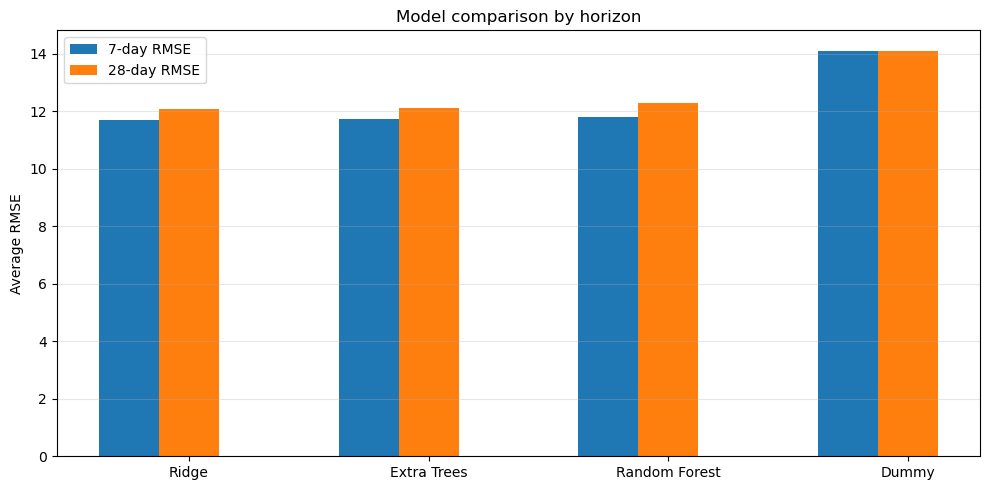

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_7d["model"]))
width = 0.25

ax.bar(x - width, results_7d["RMSE"], width, label="7-day RMSE")
ax.bar(x, results_28d["RMSE"], width, label="28-day RMSE")
ax.set_xticks(x)
ax.set_xticklabels(results_7d["model"])
ax.set_ylabel("Average RMSE")
ax.set_title("Model comparison by horizon")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Actual vs predicted plot

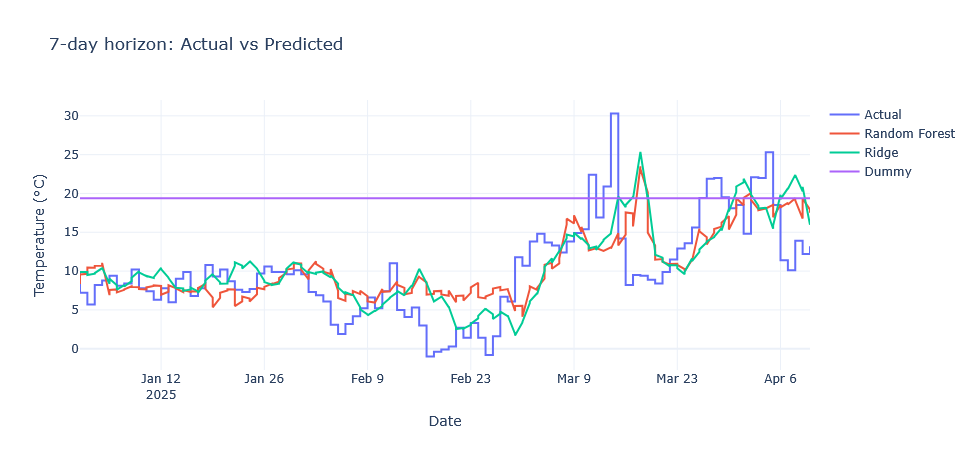

In [16]:
target_idx = 0
n = min(200, len(test_7d))

dates = test_7d["time"].iloc[:n]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=dates,
    y=y_test_7d.iloc[:n, target_idx],
    mode="lines",
    name="Actual"
))

fig.add_trace(go.Scatter(
    x=dates,
    y=preds_7d["Random Forest"][:n, target_idx],
    mode="lines",
    name="Random Forest"
))

fig.add_trace(go.Scatter(
    x=dates,
    y=preds_7d["Ridge"][:n, target_idx],
    mode="lines",
    name="Ridge"
))

fig.add_trace(go.Scatter(
    x=dates,
    y=preds_7d["Dummy"][:n, target_idx],
    mode="lines",
    name="Dummy"
))

fig.update_layout(
    title="7-day horizon: Actual vs Predicted",
    xaxis_title="Date",
    yaxis_title="Temperature (°C)",
    template="plotly_white",
    width=950,
    height=450,
    hovermode="x unified",
)

fig.show()

# Warm-season diagnostic check

In [17]:
warm_months = [4, 5, 6, 7, 8, 9]

warm_7d = test_7d[test_7d["time"].dt.month.isin(warm_months)].copy()
warm_28d = test_28d[test_28d["time"].dt.month.isin(warm_months)].copy()

print("Warm season 7-day rows:", len(warm_7d))
print("Warm season 28-day rows:", len(warm_28d))

Warm season 7-day rows: 1830
Warm season 28-day rows: 1830
